In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip install -q datasets PyYAML scikit-learn

In [3]:
from pathlib import Path

import torch


PROJECT_ROOT = Path(
    "/content/drive/MyDrive/ATML/PA1"
)

REPO_ROOT = Path(
    "/content/drive/MyDrive/ATML/PA1-repo"
)

TASK3_REPO_ROOT = (
    REPO_ROOT / "task3"
)

PACS_ROOT = (
    PROJECT_ROOT / "datasets/PACS"
)

SOURCE_SPLIT_PATH = (
    REPO_ROOT
    / "shared/splits/"
    "pacs_sketch_seed6304.json"
)

ERM_CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "task2/checkpoints/"
    "source_only_best.pt"
)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)
print(
    "PACS exists:",
    PACS_ROOT.exists(),
)
print(
    "Source split exists:",
    SOURCE_SPLIT_PATH.exists(),
)
print(
    "ERM checkpoint exists:",
    ERM_CHECKPOINT_PATH.exists(),
)

Device: cuda
PACS exists: True
Source split exists: True
ERM checkpoint exists: True


In [4]:
%cd /content/drive/MyDrive/ATML/PA1-repo

import json

import yaml

import matplotlib.pyplot as plt

import pandas as pd

import torch

from datasets import load_from_disk

from common.seed import set_seed

from shared.pacs_protocol import (
    load_pacs_protocol,
)

from task2.evaluation.source_validation import (
    evaluate_source_domains,
)

from task2.models.classifier_head import (
    PACSClassifier,
)

from task3.data.source_loaders import (
    build_task3_source_datasets,
    build_task3_source_loaders,
)


SEED = 6304

set_seed(SEED)

with (
    TASK3_REPO_ROOT
    / "configs/base.yaml"
).open(
    "r",
    encoding="utf-8",
) as config_file:
    base_config = yaml.safe_load(
        config_file
    )

with (
    TASK3_REPO_ROOT
    / "configs/erm.yaml"
).open(
    "r",
    encoding="utf-8",
) as config_file:
    method_config = yaml.safe_load(
        config_file
    )

print(
    "Method:",
    method_config["method"]["name"],
)

print(
    "Retrain ERM:",
    method_config["method"][
        "retrain"
    ],
)

print(
    "Target access stage:",
    base_config["data_policy"][
        "target_access_stage"
    ],
)

print(
    "Target images allowed:",
    base_config["selection"][
        "use_target_images"
    ],
)

/content/drive/.shortcut-targets-by-id/1tphHcVs5KfBbfa3Y2U6Gt0Lo7AWXysa4/ATML/PA1-repo
Method: erm
Retrain ERM: False
Target access stage: final_evaluation_only
Target images allowed: False


In [5]:
pacs_dataset = load_from_disk(
    str(PACS_ROOT)
)

pacs_protocol = load_pacs_protocol(
    SOURCE_SPLIT_PATH
)

source_datasets = (
    build_task3_source_datasets(
        dataset=pacs_dataset,
        protocol=pacs_protocol,
    )
)

print(
    "Accessible dataset groups:",
    list(source_datasets.keys()),
)

print(
    "Training domains:",
    list(
        source_datasets[
            "source_train"
        ].keys()
    ),
)

print(
    "Validation domains:",
    list(
        source_datasets[
            "source_validation"
        ].keys()
    ),
)

print(
    "Any target dataset created:",
    any(
        "target" in key.lower()
        for key in (
            source_datasets.keys()
        )
    ),
)

Accessible dataset groups: ['source_train', 'source_validation']
Training domains: ['photo', 'art_painting', 'cartoon']
Validation domains: ['photo', 'art_painting', 'cartoon']
Any target dataset created: False


In [6]:
source_loaders = (
    build_task3_source_loaders(
        datasets=source_datasets,
        source_batch_size=(
            base_config["batching"][
                "examples_per_source_domain"
            ]
        ),
        evaluation_batch_size=(
            base_config["batching"][
                "evaluation_batch_size"
            ]
        ),
        number_of_workers=(
            base_config["batching"][
                "number_of_workers"
            ]
        ),
        seed=SEED,
    )
)

print(
    "Steps per training epoch:",
    source_loaders[
        "steps_per_epoch"
    ],
)

print(
    "Source validation samples:"
)

for domain_name, dataset in (
    source_datasets[
        "source_validation"
    ].items()
):
    print(
        domain_name,
        len(dataset),
    )

Steps per training epoch: 234
Source validation samples:
photo 334
art_painting 410
cartoon 469


In [7]:
checkpoint = torch.load(
    ERM_CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False,
)

model = PACSClassifier(
    number_of_classes=7
).to(DEVICE)

model.load_state_dict(
    checkpoint["model_state_dict"],
    strict=True,
)

model.eval()

print(
    "Checkpoint epoch:",
    checkpoint["epoch"],
)

print(
    "Selection metric:",
    checkpoint[
        "selection_metric"
    ],
)

print(
    "Source-selection score:",
    checkpoint[
        "selection_score"
    ],
)

print(
    "Model retrained for Task 3:",
    False,
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 117MB/s]


Checkpoint epoch: 12
Selection metric: mean_source_validation_macro_f1
Source-selection score: 0.9366743407680399
Model retrained for Task 3: False


In [8]:
source_validation_results = (
    evaluate_source_domains(
        model=model,
        validation_loaders=(
            source_loaders[
                "source_validation"
            ]
        ),
        device=DEVICE,
        number_of_classes=7,
    )
)

source_result_rows = []

for domain_name, metrics in (
    source_validation_results[
        "domains"
    ].items()
):
    source_result_rows.append(
        {
            "method": "erm",
            "domain": domain_name,
            "accuracy": (
                metrics["accuracy"]
            ),
            "macro_f1": (
                metrics["macro_f1"]
            ),
            "loss": metrics["loss"],
            "number_of_samples": (
                metrics[
                    "number_of_samples"
                ]
            ),
        }
    )

source_result_table = pd.DataFrame(
    source_result_rows
)

source_result_path = (
    TASK3_REPO_ROOT
    / "results/"
    "erm_source_validation.csv"
)

source_result_table.to_csv(
    source_result_path,
    index=False,
)

print(
    source_result_table.to_string(
        index=False
    )
)

print()
print(
    "Mean source accuracy:",
    source_validation_results[
        "aggregate"
    ]["mean_accuracy"],
)

print(
    "Mean source macro-F1:",
    source_validation_results[
        "aggregate"
    ]["mean_macro_f1"],
)

print(
    "Worst source accuracy:",
    source_validation_results[
        "aggregate"
    ]["worst_accuracy"],
)

print(
    "Worst source macro-F1:",
    source_validation_results[
        "aggregate"
    ]["worst_macro_f1"],
)

method       domain  accuracy  macro_f1     loss  number_of_samples
   erm        photo  0.961078  0.954999 0.097523                334
   erm art_painting  0.904878  0.898575 0.392316                410
   erm      cartoon  0.955224  0.956449 0.190924                469

Mean source accuracy: 0.9403932578962934
Mean source macro-F1: 0.9366743407680399
Worst source accuracy: 0.9048780487804878
Worst source macro-F1: 0.8985752686205901


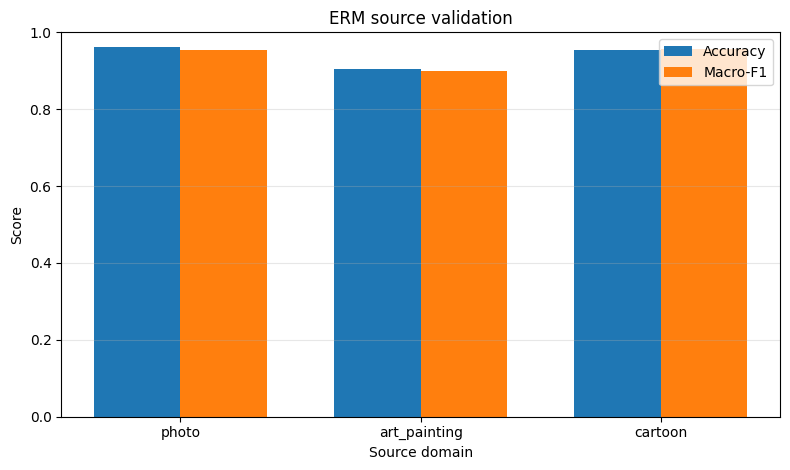

Figure saved to: /content/drive/MyDrive/ATML/PA1-repo/task3/figures/erm_source_validation.png


In [9]:
figure, axis = plt.subplots(
    figsize=(8, 4.8),
)

x_positions = range(
    len(source_result_table)
)

bar_width = 0.36

axis.bar(
    [
        position - bar_width / 2
        for position in x_positions
    ],
    source_result_table[
        "accuracy"
    ],
    width=bar_width,
    label="Accuracy",
)

axis.bar(
    [
        position + bar_width / 2
        for position in x_positions
    ],
    source_result_table[
        "macro_f1"
    ],
    width=bar_width,
    label="Macro-F1",
)

axis.set_xticks(
    list(x_positions)
)

axis.set_xticklabels(
    source_result_table[
        "domain"
    ]
)

axis.set_ylim(0.0, 1.0)
axis.set_xlabel("Source domain")
axis.set_ylabel("Score")
axis.set_title(
    "ERM source validation"
)
axis.grid(
    axis="y",
    alpha=0.3,
)
axis.legend()

figure.tight_layout()

figure_path = (
    TASK3_REPO_ROOT
    / "figures/"
    "erm_source_validation.png"
)

figure_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

figure.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to:",
    figure_path,
)

In [10]:
erm_metadata = {
    "method": "erm",
    "seed": SEED,
    "reused_task2_checkpoint": True,
    "retrained_for_task3": False,
    "checkpoint_filename": (
        ERM_CHECKPOINT_PATH.name
    ),
    "selected_epoch": int(
        checkpoint["epoch"]
    ),
    "selection_metric": (
        checkpoint[
            "selection_metric"
        ]
    ),
    "selection_score": float(
        checkpoint[
            "selection_score"
        ]
    ),
    "training_history_reference": (
        "task2/results/"
        "source_only_training_history.csv"
    ),
    "target_images_loaded": False,
    "target_labels_used": False,
    "source_validation": {
        domain_name: {
            "accuracy": float(
                metrics["accuracy"]
            ),
            "macro_f1": float(
                metrics["macro_f1"]
            ),
            "loss": float(
                metrics["loss"]
            ),
            "number_of_samples": int(
                metrics[
                    "number_of_samples"
                ]
            ),
        }
        for domain_name, metrics
        in source_validation_results[
            "domains"
        ].items()
    },
    "aggregate_source_validation": {
        key: float(value)
        for key, value
        in source_validation_results[
            "aggregate"
        ].items()
    },
}

metadata_path = (
    TASK3_REPO_ROOT
    / "results/"
    "erm_metadata.json"
)

with metadata_path.open(
    "w",
    encoding="utf-8",
) as metadata_file:
    json.dump(
        erm_metadata,
        metadata_file,
        indent=2,
    )

print(
    json.dumps(
        erm_metadata,
        indent=2,
    )
)

{
  "method": "erm",
  "seed": 6304,
  "reused_task2_checkpoint": true,
  "retrained_for_task3": false,
  "checkpoint_filename": "source_only_best.pt",
  "selected_epoch": 12,
  "selection_metric": "mean_source_validation_macro_f1",
  "selection_score": 0.9366743407680399,
  "training_history_reference": "task2/results/source_only_training_history.csv",
  "target_images_loaded": false,
  "target_labels_used": false,
  "source_validation": {
    "photo": {
      "accuracy": 0.9610778443113772,
      "macro_f1": 0.9549985174394315,
      "loss": 0.09752263708742792,
      "number_of_samples": 334
    },
    "art_painting": {
      "accuracy": 0.9048780487804878,
      "macro_f1": 0.8985752686205901,
      "loss": 0.39231610723384996,
      "number_of_samples": 410
    },
    "cartoon": {
      "accuracy": 0.9552238805970149,
      "macro_f1": 0.956449236244098,
      "loss": 0.19092371392605909,
      "number_of_samples": 469
    }
  },
  "aggregate_source_validation": {
    "mean_accura